In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [2]:
# Load the dataset
fr = pd.read_csv(r"C:\D drive\desktop\python\linear-regression-advertisement&sales\advertising.csv")

In [3]:
# Detailed study of the dataset
print(fr.head())
print(fr.info())
print(fr.shape)
print(fr.describe())
print(fr.isnull().sum())
print(fr.duplicated().sum())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
(200, 4)
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000  

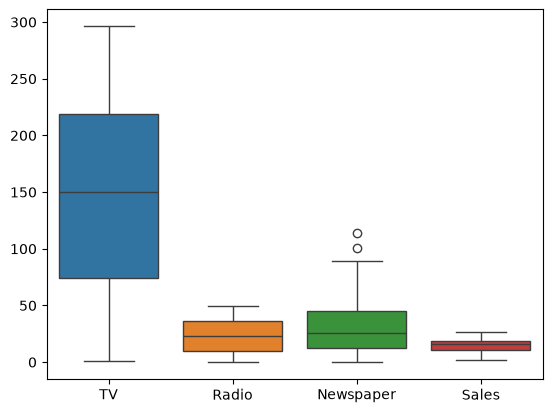

In [4]:
# Checking for any outliers
sns.boxplot(data=fr)
plt.show()

In [5]:
#
Q1 = fr['Newspaper'].quantile(0.25)
Q3 = fr['Newspaper'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = fr[(fr['Newspaper'] < lower) | (fr['Newspaper'] > upper)]

print(outliers)

        TV  Radio  Newspaper  Sales
16    67.8   36.6      114.0   12.5
101  296.4   36.3      100.9   23.8


In [6]:
# Replacing the outliers with median value
median = fr['Newspaper'].median()

fr.loc[fr['Newspaper'] > upper, 'Newspaper'] = median
fr.loc[fr['Newspaper'] < lower, 'Newspaper'] = median

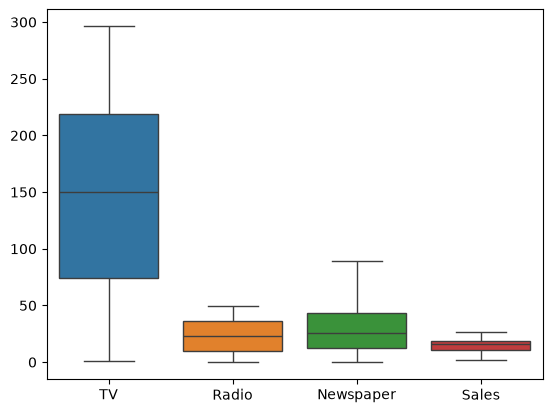

In [7]:
# Re-Checking for any outliers after making changes
sns.boxplot(data=fr)
plt.show()

In [8]:
# Prepare data for regression modeling:
X = fr[['TV', 'Radio', 'Newspaper']]
Y = fr['Sales']

In [ ]:
# Split the data and train the linear regression model
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.05,0.1 ,0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.676
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [10]:
#
Y_pred = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(Y_test, Y_pred))
print("Mean Squared Error:", mean_squared_error(Y_test, Y_pred))
print("R-squared:", r2_score(Y_test, Y_pred))
print("Root Mean Squared Error:", root_mean_squared_error(Y_test, Y_pred))



Mean Absolute Error: 1.2873891158610444
Mean Squared Error: 2.9397473693722604
R-squared: 0.9048659313302031
Root Mean Squared Error: 1.714569149778527


In [11]:
# Printing the Intercept of the features
print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

Intercept: 4.675558874282826
TV: 0.05456660331947051
Radio: 0.10022354694984
Newspaper: 0.005982578965057446


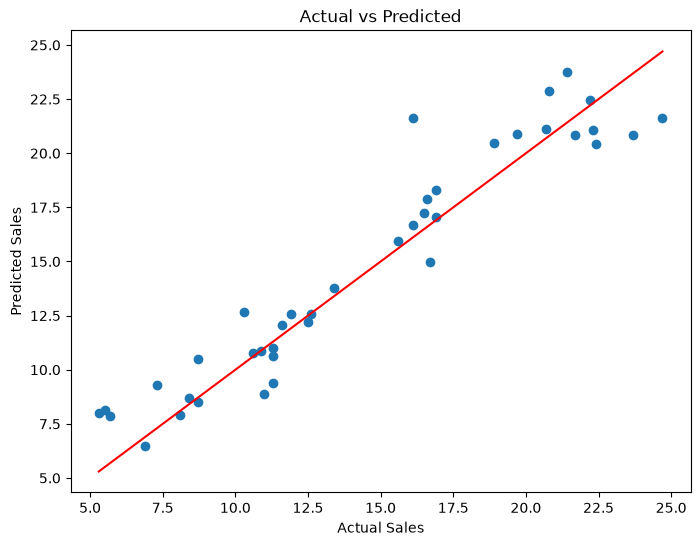

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(Y_test, Y_pred)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color='red'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.show()


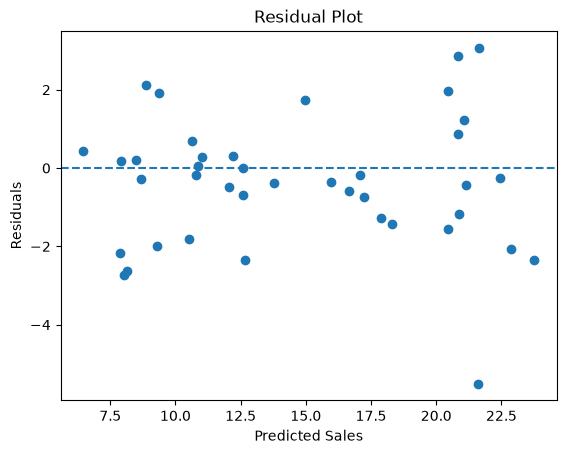

In [13]:
residuals = Y_test - Y_pred

plt.scatter(Y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()